## Binary Classification using a Quantum Tree Tensor Network - A simple example for supervised learning with quantum circuits
In this notebook, we create a small-scale 2-class dataset, so we can use a parametrized quantum neural netork (here we use a quantum tree tensor network as an Ansatz) as a binary classifier and optimize the trainable parameters in the network accordingly. The single measurement of the quantum circuit returns one value that can distuinguish among the two classes. This notebook is based on the Pennylane TTN tutorial from https://pennylane.ai/qml/demos/tutorial_tn_circuits/.

In [101]:
%%capture
# install packages
!pip install pennylane
!pip install matplotlib

In [102]:
%%capture
# import packages
import pennylane.numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import warnings
warnings.filterwarnings('ignore')

## 1. We create a very simple dataset with 2 classes for our binary classifier

We create two classes: one has diagonal elements, the other one bars.

In [103]:
# define simple dataset
bars_and_diagonals = [[1, 0, 0, 1], [0, 1, 1, 0], [1, 0, 1, 0], [0, 1, 0, 1]]


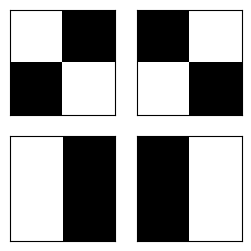

In [104]:
# visualize the dataset
j = 1
plt.figure(figsize=[3, 3])
for i in bars_and_diagonals:
    plt.subplot(2, 2, j)
    j += 1
    plt.imshow(np.reshape(i, [2, 2]), cmap="gray")
    plt.xticks([])
    plt.yticks([])

## 2. Define the embedding circuit:
In this exemplary case with 4-bit low dimensional input data, we can do basis encoding. 
For basis encoding, we encode a binary input data such that a $1$ is encoded by applying a $X$-gate, and nothing has to be done for encoding a $0$.
In Pennylane, there is the built-in function ```qml.BasisState(input_data, wires=wires)``` available, below we write out the encoding to see better how it works. 

**TODO**: Do binary encoding of the input data, i.e. apply an X-gate for each bit that is 1 in the input data, and do nothing for bits that are 0.

In [105]:
def encoding(input_data):
    ###############################################################
    # add basis encoding of classical data into quantum states

    ###############################################################
    return 0 
def encoding(input_data):
    wires = range(4)
    for i, bit in enumerate(input_data):
        if bit == 1:
            qml.X(wires=wires[i])

**Question**: What happens if you test other encoidng schemes?

## 2. Define the parametrized quantum circuit acting as the classifier (with trainable parameters), here we use a Quantum TTN as discussed in the lecture:
In this exemplary case with 4-bit low dimensional input data, we use a 4 qubit quantum tree tensor network (defined via ```qml.TTN```) as a classifier. Instead of the general unitary gates we have seen on the Slides, we use rotational Y-gates here, they each have a single angle that can be iteratively optimized in the future. This circuit can be visualized as shown in the figure below.

![caption](figures/example_ttn.png)

**TODO**: Let us first implement one block that is later passed in the qml.TTN function. 
The block is structured as given below, it consists of two rotational Y-gates and a CNOT gate.
Note that an RY gate has two input the angle (named 'weights' here) and the wires it acts on, while a CNOT gate has only the wires as input.

![caption](figures/block_ttn.png)

In [106]:
# define the quantum circuit block in the TTN used for binary classification
def block(weights, wires):
    ###############################################################
    # define block of gates here, 
    # consisting of two RY gates and a CNOT gate, as shown in the figure above
    ###############################################################
    return 0 

def block(weights, wires):
    qml.RY(weights[0], wires=wires[0])
    qml.RY(weights[1], wires=wires[1])
    qml.CNOT(wires=wires)

In [107]:
# create a quantum circuit with 4 qubits
dev = qml.device("default.qubit", wires=4)

# as we discussed the parameter-shift rule is a method for computing the gradient of quantum circuits with respect to their parameters.
@qml.qnode(dev, diff_method="parameter-shift")
def circuit(image, template_weights):
    # we first encode the input data 
    encoding(image)
    qml.Barrier()
    # then we apply the quantum tree tensor 
    # network Ansatz for binary classification
    qml.TTN(
        wires=range(4),
        n_block_wires=2,
        block=block,
        n_params_block=2,
        template_weights=template_weights,
    )
    # we measure the expectation value of PauliZ on the last qubit,
    # we obtain one output value allowing for binary classification
    return qml.expval(qml.PauliZ(wires=3))


**Question**: Can you also imlement the TTN circuit yourself by using the basic gates (without using the built-in function ```qml.TTN```)?

## 3. Check the correct implementation of the quantum circuit

**Question**: Can you confirm that the circuit is correctly implemented by checking the output state of the circuit for a specific input data?

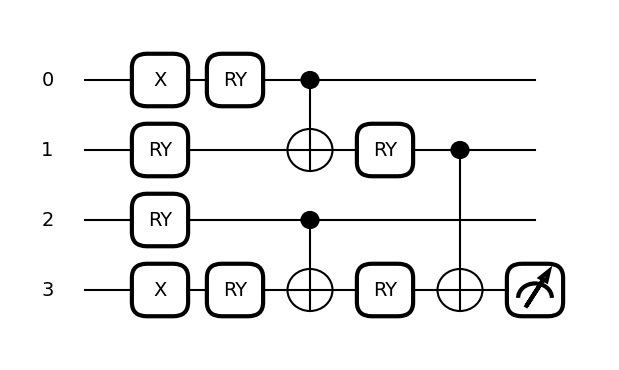

In [108]:
# Initialize random trainable parameters for the TTN circuit
weights = np.random.random(size=[3, 2])
# visualize the circuit
fig, ax = qml.draw_mpl(circuit, level="device")(bars_and_diagonals[0], weights)
fig.set_size_inches((6, 3.5))

## 4. Implement the cost function for optimization
We can write the cost function as follows:
$$
    C(\theta)= \sum_{x_i \in diagonals} f(x_i, \theta)  - \sum_{x_i \in bars} f(x_i, \theta) .
$$
This means, that stripes are indicated by a more positive value and bars with a negative one.

In [109]:
def costfunc(params):
    cost = 0
    mid = len(bars_and_diagonals) / 2

    for i, x in enumerate(bars_and_diagonals):
        if i < mid:
            # diagonals
            cost += circuit(x, params)
        else:
            # bars
            cost -= circuit(x, params)

    return cost


## 5. Optimize the initially randomly initialized parameters

**Question**: Below, a specific optimizer is used, but you can also try out other optimizers and compare the results. Do you get the same results with different optimizers?

In [110]:
# initially all parameters are randomly initialized
params = np.random.random(size=[3, 2], requires_grad=True)
# define the optimizer and run the optimization
optimizer = qml.GradientDescentOptimizer(stepsize=0.1)
# iteratively optimize the parameters
print('Number of training steps: 50')
cost_list = []
for k in range(50):
    if k % 10 == 0:
        print(f"Step {k}, cost: {costfunc(params)}")
    # update the parameters
    cost_list.append(costfunc(params))
    params = optimizer.step(costfunc, params)

Number of training steps: 50
Step 0, cost: -0.7559952341866023
Step 10, cost: -3.9959203667172156
Step 20, cost: -3.9999998505201875
Step 30, cost: -3.999999999994536
Step 40, cost: -3.999999999999999


Text(0.5, 1.0, 'Convergence of simple cost function during training')

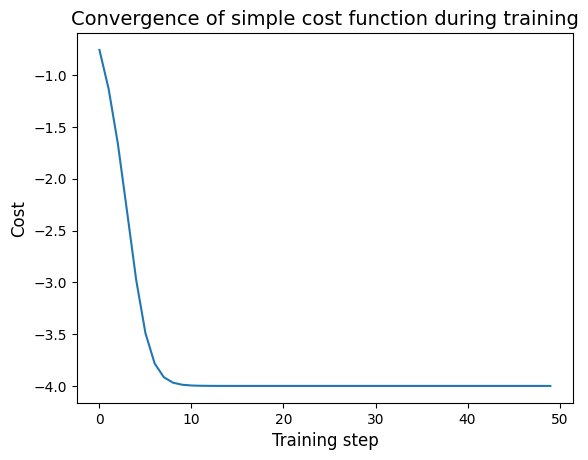

In [111]:
# visualize the convergence of the cost function during training
plt.figure()
plt.plot(cost_list)
plt.xlabel('Training step', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.title('Convergence of simple cost function during training', fontsize=14)

## 5. Check the prediction results after optimizing the parameters

**Note**: Think about the result you would get after optimization based on the cost function you have defined. Do you get the expected results? What happens if you multiply the cost function by -1?

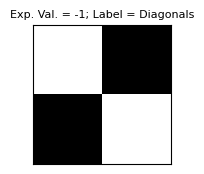

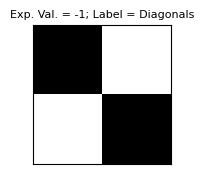

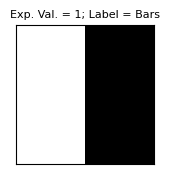

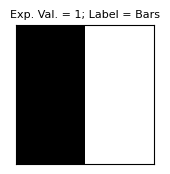

In [112]:
for image in bars_and_diagonals:
    plt.figure(figsize=[1.8, 1.8])
    plt.imshow(np.reshape(image, [2, 2]), cmap="gray")
    plt.title(
        f"Exp. Val. = {circuit(image,params):.0f};"
        + f" Label = {'Bars' if circuit(image,params)>0 else 'Diagonals'}",
        fontsize=8,
    )
    plt.xticks([])
    plt.yticks([])